100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 227kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.37MB/s]


Đang chạy Epoch 1/5...
Đang chạy Epoch 2/5...
Đang chạy Epoch 3/5...
Đang chạy Epoch 4/5...
Đang chạy Epoch 5/5...


/tmp/ipykernel_570/2810473881.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


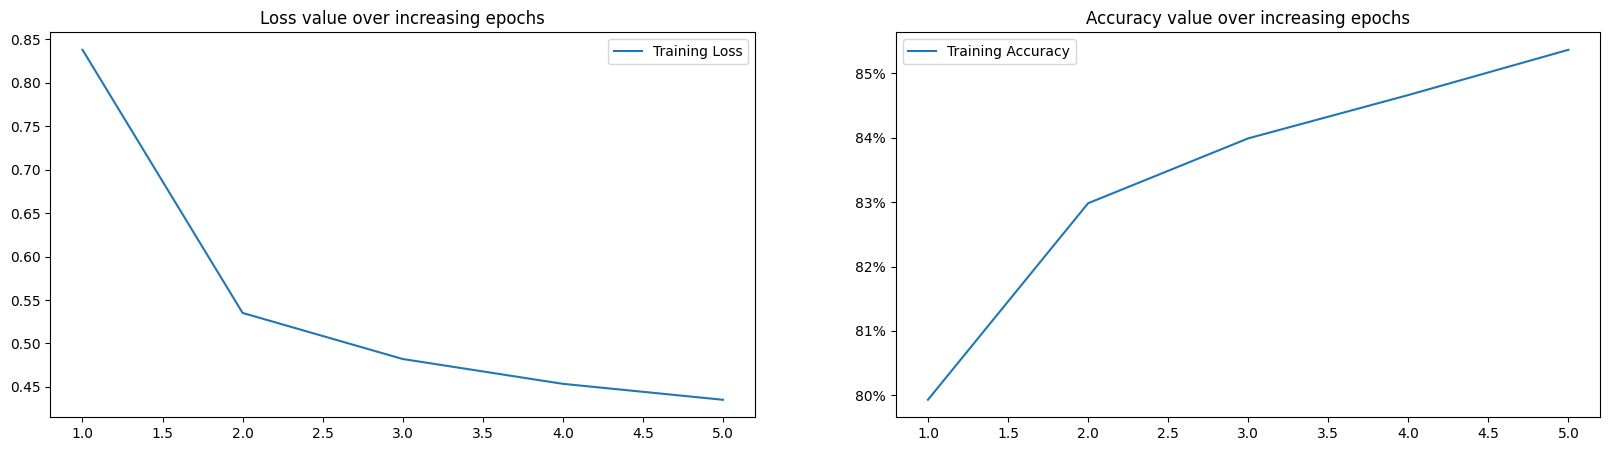

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt

# 1. Khởi tạo thiết bị và tải dữ liệu
device = "cuda" if torch.cuda.is_available() else "cpu"
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

# 2. Xây dựng lớp Dataset (Đã chia tỷ lệ dữ liệu cho 255)
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

# 3. Tạo DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

# 4. Xây dựng Mô hình, Hàm Loss và Optimizer
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

# 5. Hàm huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

# 6. Hàm tính độ chính xác
def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
        max_values, argmaxes = prediction.max(-1)
        is_correct = argmaxes == y
        return is_correct.cpu().numpy().tolist()

# 7. Vòng lặp Huấn luyện (5 Epochs)
trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []

for epoch in range(5):
    print(f"Đang chạy Epoch {epoch + 1}/5...")
    epoch_losses, epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

# 8. Vẽ biểu đồ
epochs = np.arange(5) + 1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()

plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.show()

Đang chạy Epoch 1/5...
Đang chạy Epoch 2/5...
Đang chạy Epoch 3/5...
Đang chạy Epoch 4/5...
Đang chạy Epoch 5/5...


/tmp/ipykernel_950/3432559116.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


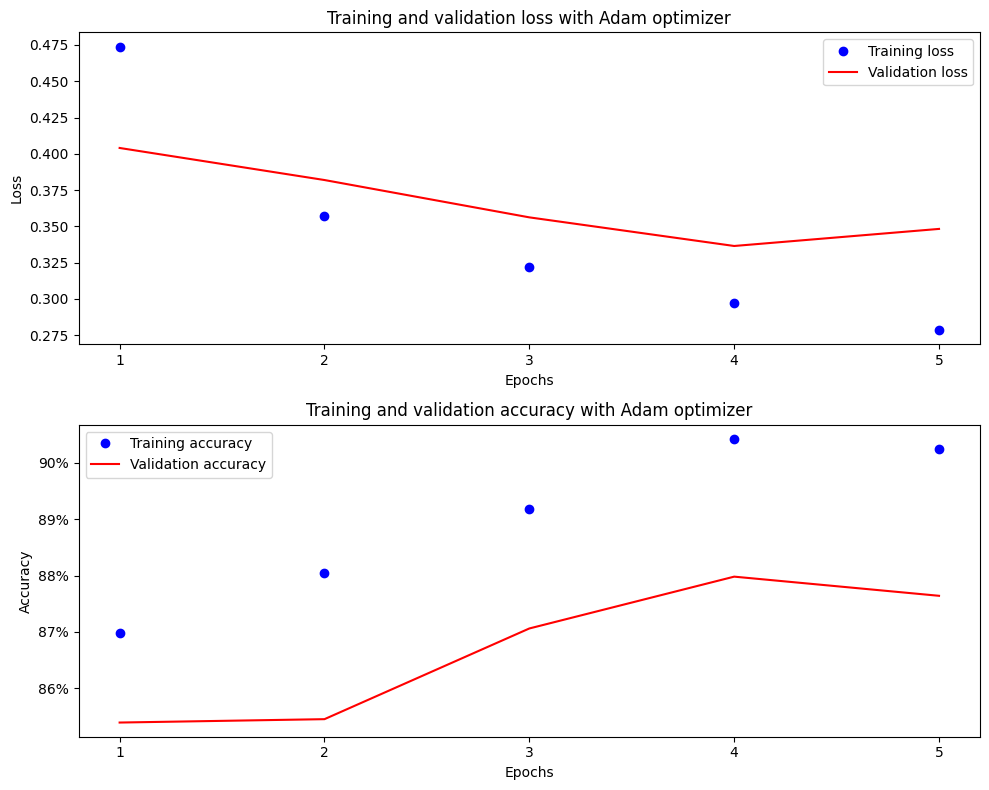

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam  # Đã đổi sang Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"
data_folder = '~/data/FMNIST'

# 1. Tải dữ liệu Huấn luyện (Train) và Xác thực (Validation)
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# 2. Xây dựng lớp Dataset (Đã chia tỷ lệ /255)
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

# 3. Tạo DataLoader cho cả Train và Validation
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# 4. Xây dựng Mô hình, Hàm Loss và Optimizer (Dùng Adam)
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    # Sử dụng Adam với tốc độ học 0.001 (1e-3)
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

# 5. Hàm huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

# 6. Các hàm tính toán độ chính xác và Loss cho Validation
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model):
    model.eval()
    prediction = model(x)
    v_loss = loss_fn(prediction, y)
    return v_loss.item()

# 7. Vòng lặp Huấn luyện và Đánh giá
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

epochs = 5  # Có thể tăng lên 10 nếu muốn quan sát dài hơn

for epoch in range(epochs):
    print(f"Đang chạy Epoch {epoch + 1}/{epochs}...")
    train_epoch_losses, train_epoch_accuracies = [], []

    # Huấn luyện trên tập Train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    # Đánh giá trên tập Train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Đánh giá trên tập Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

# 8. Vẽ biểu đồ so sánh Train và Validation
epochs_range = np.arange(epochs) + 1
plt.figure(figsize=(10, 8))

plt.subplot(211)
plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(212)
plt.plot(epochs_range, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()

plt.tight_layout()
plt.show()

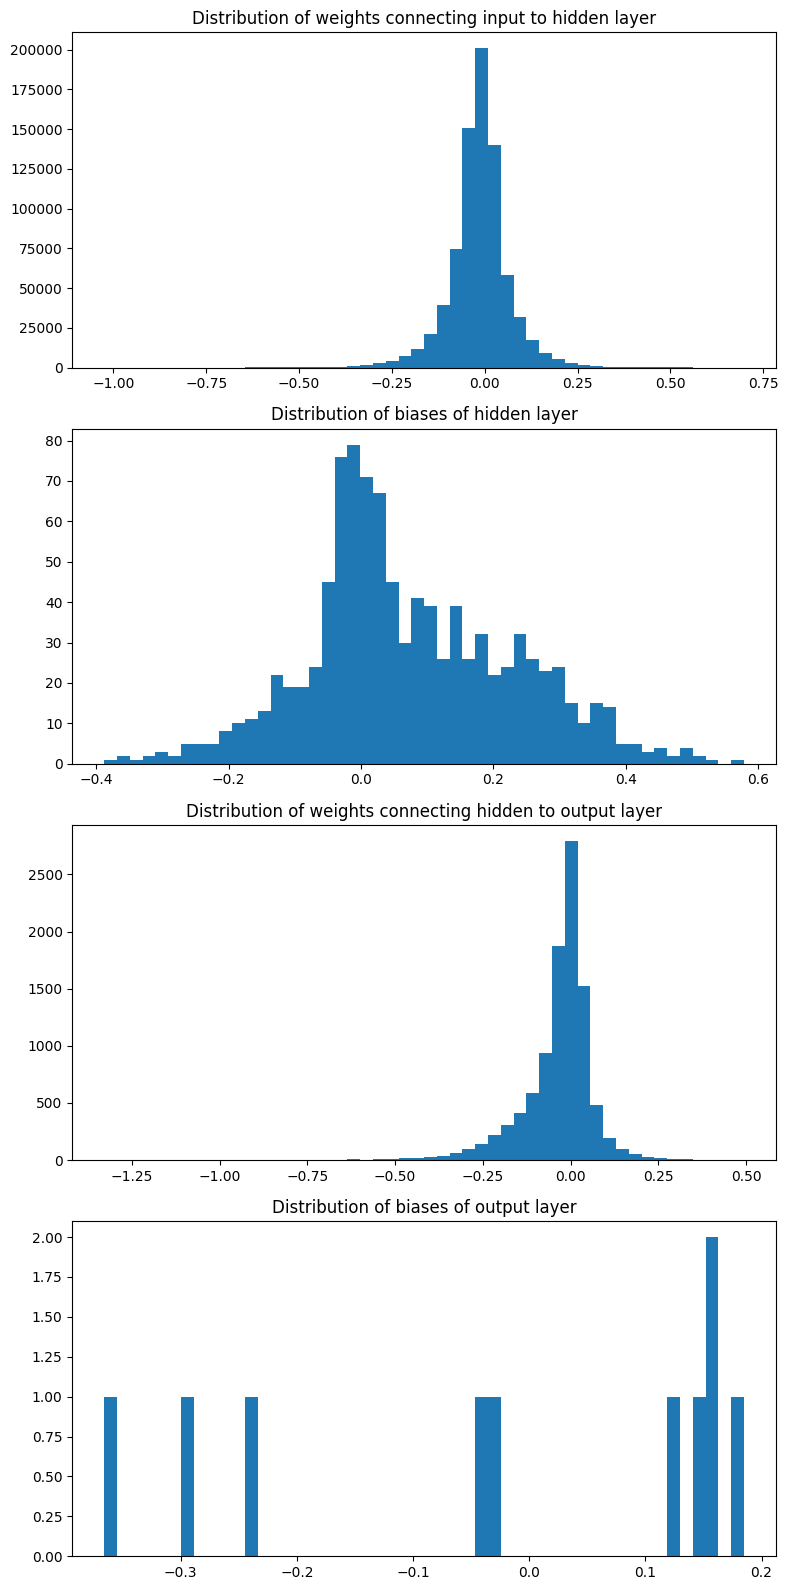

In [ ]:
import matplotlib.pyplot as plt

# 1. Trích xuất các trọng số (weights) và độ lệch (biases) từ mô hình
# Cần dùng .detach().cpu().numpy().flatten() để tách dữ liệu khỏi GPU và chuyển thành mảng 1 chiều
hidden_weights = model[0].weight.detach().cpu().numpy().flatten()
hidden_biases = model[0].bias.detach().cpu().numpy().flatten()

output_weights = model[2].weight.detach().cpu().numpy().flatten()
output_biases = model[2].bias.detach().cpu().numpy().flatten()

# 2. Khởi tạo khung vẽ gồm 4 biểu đồ xếp dọc
fig, axs = plt.subplots(4, 1, figsize=(8, 16))

# Biểu đồ 1: Phân phối trọng số kết nối đầu vào với lớp ẩn
axs[0].hist(hidden_weights, bins=50, color='#1f77b4')
axs[0].set_title('Distribution of weights connecting input to hidden layer')

# Biểu đồ 2: Phân phối độ lệch của lớp ẩn
axs[1].hist(hidden_biases, bins=50, color='#1f77b4')
axs[1].set_title('Distribution of biases of hidden layer')

# Biểu đồ 3: Phân phối trọng số kết nối lớp ẩn với đầu ra
axs[2].hist(output_weights, bins=50, color='#1f77b4')
axs[2].set_title('Distribution of weights connecting hidden to output layer')

# Biểu đồ 4: Phân phối độ lệch của lớp đầu ra
axs[3].hist(output_biases, bins=50, color='#1f77b4')
axs[3].set_title('Distribution of biases of output layer')

# 3. Hiển thị biểu đồ
plt.tight_layout()
plt.show()

III. NHẬN DẠNG QUẦN ÁO GIÀY DÉP THỜI TRANG VỚI BỘ
DỮ LIỆU FASHION-MNIST:
1. Tạo project Lab5 và tạo môi trường ảo để cài đặt các thư viện cần thiết cho Lab5
2. Chuẩn bị dữ liệu cho bài toán phân loại:

In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
from torchvision import datasets
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data_folder = './data'

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 224kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.21MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


In [ ]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [ ]:
unique_values = tr_targets.unique()

print(f'tr_images & tr_targets:')
print(f'X - {tr_images.shape}')
print(f'Y - {tr_targets.shape}')
print(f'Y - Unique Values : {unique_values}')

print(f'TASK:')
print(f'{len(unique_values)} class Classification')

print(f'UNIQUE CLASSES:')
print(f'{fmnist.classes}')

tr_images & tr_targets:
X - torch.Size([60000, 28, 28])
Y - torch.Size([60000])
Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
10 class Classification
UNIQUE CLASSES:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


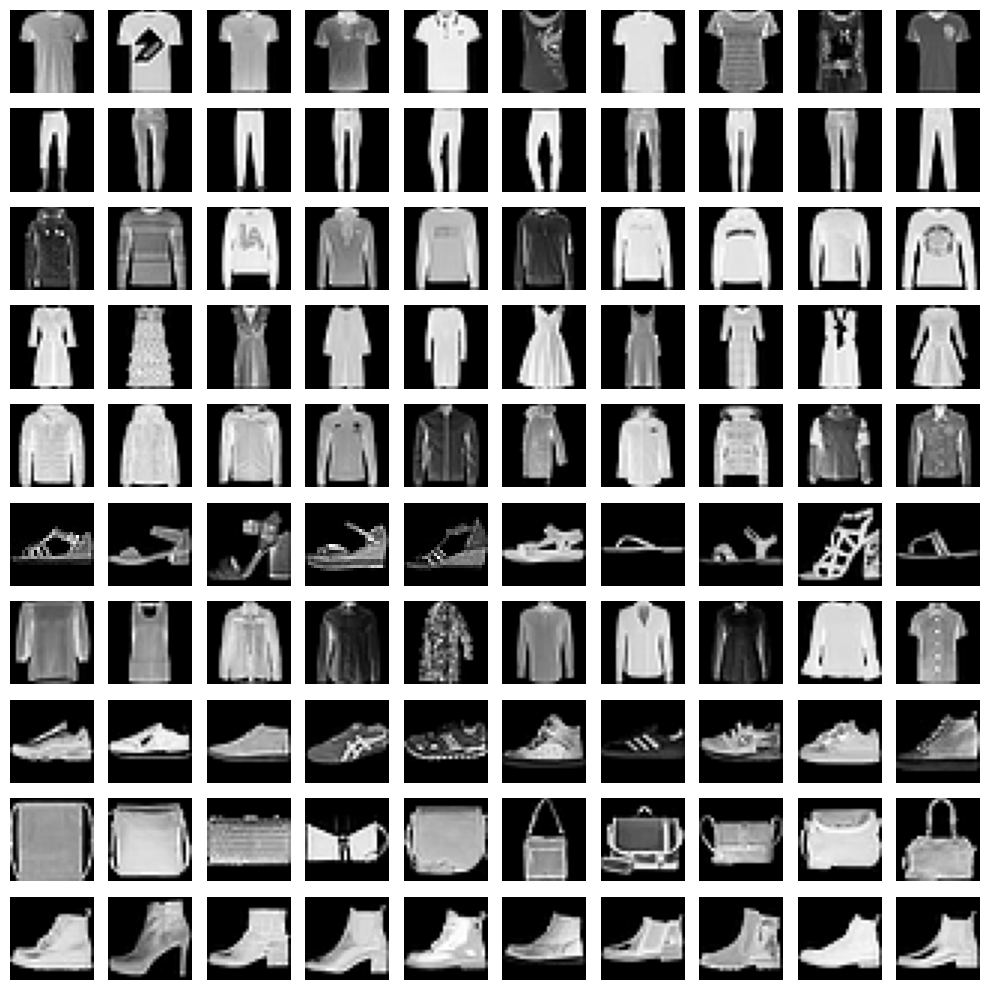

In [ ]:
R, C = len(tr_targets.unique()), 10

fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):

    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')

        ix = np.random.choice(label_x_rows)

        x = tr_images[ix]

        plot_cell.imshow(x, cmap='gray')

plt.tight_layout()
plt.show()

3. Huấn luyện mạng nơ-ron

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

from torchvision import datasets

data_folder = './data'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

In [ ]:
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

In [ ]:
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    return trn_dl

In [ ]:
from torch.optim import SGD

def get_model():

    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

In [ ]:
def train_batch(x, y, model, optimizer, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    return batch_loss.item()

In [ ]:
@torch.no_grad()

def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

In [ ]:
trn_dl = get_data()

model, loss_fn, optimizer = get_model()

losses = []
accuracies = []

for epoch in range(5):

    print("Epoch:", epoch)

    epoch_losses = []
    epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(x, y, model)

        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4


/tmp/ipykernel_570/812104151.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


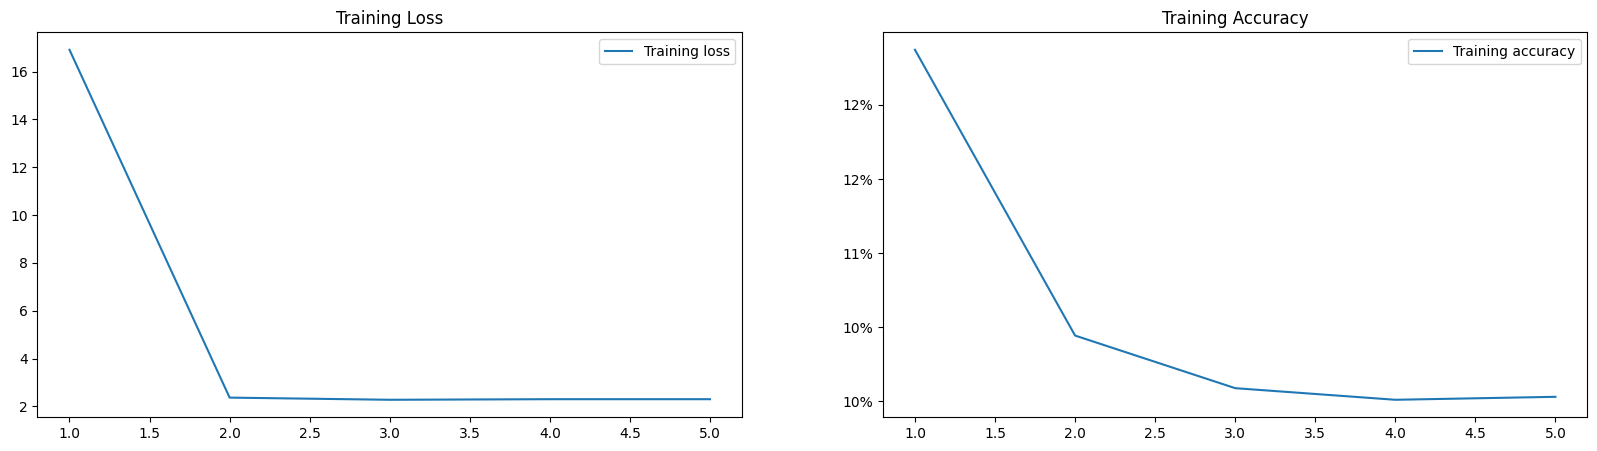

In [ ]:
epochs = np.arange(5) + 1

plt.figure(figsize=(20,5))

plt.subplot(121)
plt.title("Training Loss")
plt.plot(epochs, losses, label="Training loss")
plt.legend()

plt.subplot(122)
plt.title("Training Accuracy")
plt.plot(epochs, accuracies, label="Training accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.show()